In [2]:
import sys
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from dynamics_tools import shape_functions, element_stiffness, element_mass, compute_f1
from scipy.linalg import eigh

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "dynamics_tools.py").exists():
    for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        candidate = parent / "CIEM5220" / "Windturbine"
        if (candidate / "dynamics_tools.py").exists():
            NOTEBOOK_DIR = candidate
            break

sys.path.insert(0, str(NOTEBOOK_DIR))

x=sp.Symbol('x')

# ====== GEOMETRY & MATERIAL ========
D0 = 5                          # [m]  
t=0.08                          # [m]  
Di = D0-2*t                     # [m]
A = np.pi/4*(D0**2-Di**2)       # [m^2]
I = np.pi/64*(D0**4-Di**4)      # [m^-4]
rho = 7850                      # steel [kg/m^3] ##
E = 210e9                       # [Pa]

EI=E*I
rhoA=rho*A

Hw=36.0                         # [m]
Ha=108.0                        # [m]
L=Hw+Ha                         # [m]  

M_nacelle=6e5       # [kg] 

# ====== ROTOR PARAMETERS ========
Omega_max=7.6                   # [rpm]
f_1P=Omega_max/60               # [Hz]
f_3P=3*f_1P                     # [Hz]
f_target=1.1*f_1P               # [Hz]

print(f"1P frequency: {f_1P:.4f} Hz")
print(f"3P frequency: {f_3P:.4f} Hz")
print(f"Target f1 (>=1.1*1P): {f_target:.4f} Hz")



1P frequency: 0.1267 Hz
3P frequency: 0.3800 Hz
Target f1 (>=1.1*1P): 0.1393 Hz


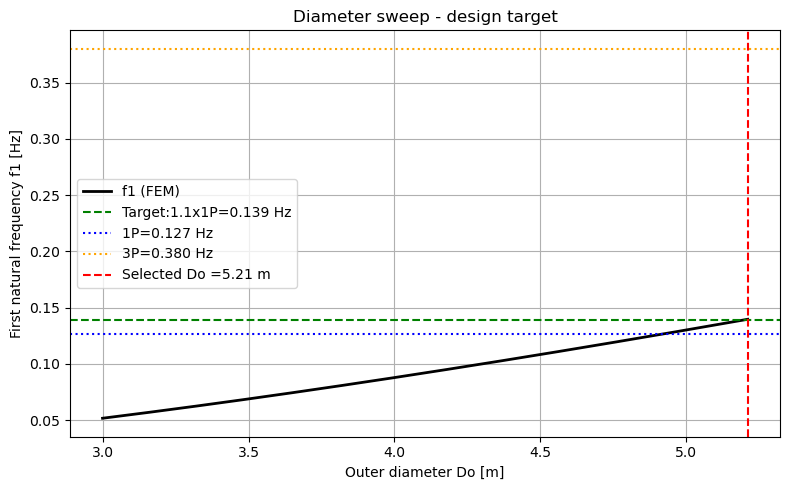


 Diameter Tuning
D/t ratio:        90
D0=               5.210 m
t=                0.0579m
f1 achieved=      0.1397 Hz
Margin above 1P = 10.3%


In [3]:
# ====== DIAMETER TUNING =======

Dt_ratio=90
D0_range=np.arange(3.0, 10.0, 0.01) # sweep diameters [m]

elements=12
le=L/elements
elem_w=int(Hw/le)        # elements in submerged zone
elem_a=elements-elem_w   # elements in air zone 

nodes          = elements+1
DOF            = 2             # (w, theta)
ndof           = nodes*DOF

# store results for plotting

D0_list=[]
f1_list=[]

for D0_try in D0_range:
    f1_try=compute_f1(elements, ndof, Dt_ratio, D0_try, E, rho, 
                      Hw, Ha, L, elem_w, elem_a, le, M_nacelle)
    D0_list.append(D0_try)
    f1_list.append(f1_try)
    if f1_try>= f_target:
        D0=D0_try
        t=D0/Dt_ratio
        break
# plot f1 vs D0
fig_sweep, ax_sweep=plt.subplots(figsize=(8,5))
ax_sweep.plot(D0_list, f1_list, 'k', linewidth=2, label='f1 (FEM)')
ax_sweep.axhline(f_target, color='green', linestyle='--', label=f'Target:1.1x1P={f_target:.3f} Hz')
ax_sweep.axhline(f_1P, color='blue', linestyle=':', label=f'1P={f_1P:.3f} Hz')
ax_sweep.axhline(f_3P, color='orange', linestyle=':', label=f'3P={f_3P:.3f} Hz')
ax_sweep.axvline(D0, color='red', linestyle='--', label=f'Selected Do ={D0:.2f} m')
ax_sweep.set_xlabel('Outer diameter Do [m]')
ax_sweep.set_ylabel('First natural frequency f1 [Hz]')
ax_sweep.set_title('Diameter sweep - design target')
ax_sweep.legend()
ax_sweep.grid(True)
plt.tight_layout()
plt.show()


print(f"\n Diameter Tuning")
print(f"D/t ratio:        {Dt_ratio}")
print(f"D0=               {D0:.3f} m")
print(f"t=                {t:.4f}m")
print(f"f1 achieved=      {f1_try:.4f} Hz")
print(f"Margin above 1P = {(f1_try/f_1P-1)*100:.1f}%")



In [4]:
# update cross-section with tuned diameter
Di=D0-2*t
A=np.pi/4*(D0**2-Di**2)
I=np.pi/64*(D0**4-Di**4)
EI=E*I
rhoA=rho*A

print(f"A={A:.6f}m^2")
print(f"I={I:.6f} m^4")



A=0.936980m^2
I=3.109321 m^4


In [5]:
# ====== FE MODEL SETUP ========

B = shape_functions(le)
Ke = element_stiffness(le, EI)
Me = element_mass(le, rhoA)

# ======= ASSEMBLY ========
K =np.zeros((ndof,ndof))
M =np.zeros((ndof,ndof))

for e in range(elements):
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i,j]
            M[dofs[i], dofs[j]] += Me[i,j]

# ===== BOUNDARY CONDITIONS =======
# clamped base: remove DOFs 0 and 1
free=np.arange(2, ndof)
K_free=K[np.ix_(free,free)]
M_free=M[np.ix_(free,free)]

# ====== SANITY CHECK ========
# Uniform load over full length, no nacelle mass
# Analytical: u_tip = qL^4/8EI, M_mudline= qL^2/2
q_check=1e3             # [N/m] uniform load
f_check=np.zeros(ndof)

for e in range(elements):
    fe=np.array([
        float(sp.integrate(Ni*q_check, (x, 0, le))) for Ni in B
    ])
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        f_check[dofs[i]]+=fe[i]
    

f_check_free         = f_check[free]
u_check              = np.linalg.solve(K_free, f_check_free)
u_tip_FE             = u_check[-2]
u_check_full         = np.zeros(ndof)
u_check_full[free]   = u_check
u_e0                 = u_check_full[0:4]
M_mudline_FE         = EI*sum(
    float(sp.diff(Ni, x, 2).subs(x, 0))*u_e0[i]
    for i, Ni in enumerate(B)
)
u_tip_analytical     = q_check*L**4/(8*EI)
M_mudline_analytical = q_check*L**2/2

print(f"\n--- Sanity Check (uniform load q={q_check} N/m, no nacelle)---")
print(f"Tip deflection FE: {u_tip_FE:.6f} m")
print(f"Tip deflection Analytical: {u_tip_analytical:.6f} m")
print(f"Mudline moment FE: {M_mudline_FE/1e6:.3f} MNm")
print(f"Mudline moment Analytical: {M_mudline_analytical/1e6:.3f} MNm")




--- Sanity Check (uniform load q=1000.0 N/m, no nacelle)---
Tip deflection FE: 0.082314 m
Tip deflection Analytical: 0.082314 m
Mudline moment FE: 10.356 MNm
Mudline moment Analytical: 10.368 MNm


In [6]:
#========= + NACELLE MASS ===========
M[ndof-2, ndof-2]+=M_nacelle
M_free=M[np.ix_(free, free)]

# ==== EIGENVALUE ANALYSIS =======
eigenvalues, eigenvectors=eigh(K_free, M_free)
omega=np.sqrt(eigenvalues)
freq=omega/(2*np.pi)

print(f"\n---Natural frequencies ---")
print(f"Mode 1: {freq[0]:.4f} Hz (target >={f_target:.4f} Hz)")
print(f"Mode 2: {freq[1]:.4f} Hz")
print(f"Soft-stiff window: {f_1P:.4f}-{f_3P:.4f} Hz")




---Natural frequencies ---
Mode 1: 0.1397 Hz (target >=0.1393 Hz)
Mode 2: 1.2122 Hz
Soft-stiff window: 0.1267-0.3800 Hz


In [7]:
# ====== RAYLEIGH DAMPING ========
#Borth modes have 2% critical damping as per assignment

zeta1=0.02           # damping ratio mode 1
zeta2=0.02           # damping ratio mode 2
w1 = omega[0]        # first natural frequency [rad/s]
w2 = omega[1]        # second natural frequency [rad/s]

alpha   = 2*w1*w2*(zeta1*w2-zeta2*w1)/(w2**2-w1**2)
beta    = 2*(zeta2*w2-zeta1*w1)/(w2**2-w1**2)
C_free  = alpha * M_free + beta * K_free

print(f"\n--- Rayleigh Damping ---")
print(f"alpha={alpha:.6f}")
print(f"beta={beta:.6f}")




--- Rayleigh Damping ---
alpha=0.031477
beta=0.004709


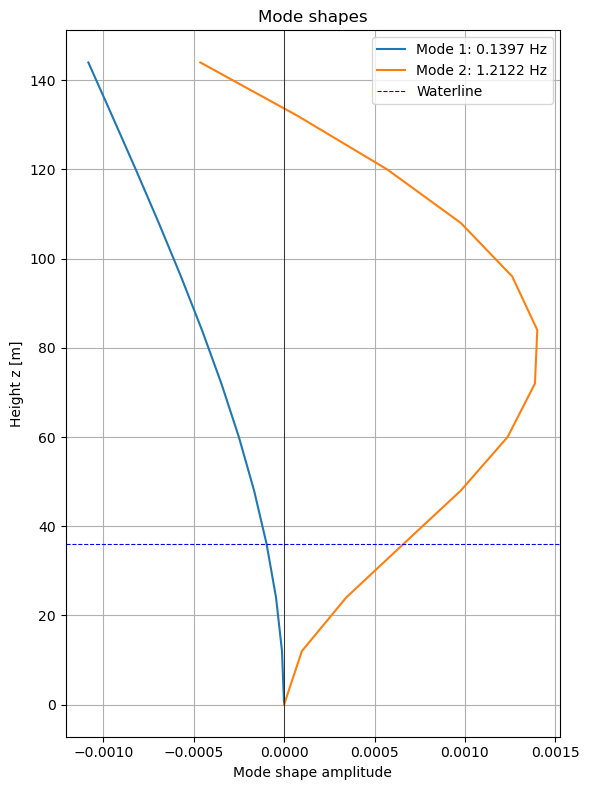

In [8]:
# ======= POST-PROCESSING =========

# Mode shapes

fig3, ax=plt.subplots(figsize=(6, 8))

# height coordinates of each node
z_nodes=np.array([i*le for i in range(nodes)])

for mode in range(2):
    # extract lateral displacement DOFs (every other DOF starting from 0)
    phi=eigenvectors[:,mode]  # full free DOF eigenvector

    # lateral displacements are even indices of free DOFs
    phi_lateral=phi[0::2]  # every other entry starting from 0
    phi_plot=np.concatenate([[0], phi_lateral])

    ax.plot(phi_plot, z_nodes, label=f'Mode {mode+1}: {freq[mode]:.4f} Hz')

ax.axhline(Hw, color= 'blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.axvline(0,color='k', linewidth=0.5)
ax.set_xlabel('Mode shape amplitude')
ax.set_ylabel('Height z [m]')
ax.set_title('Mode shapes')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



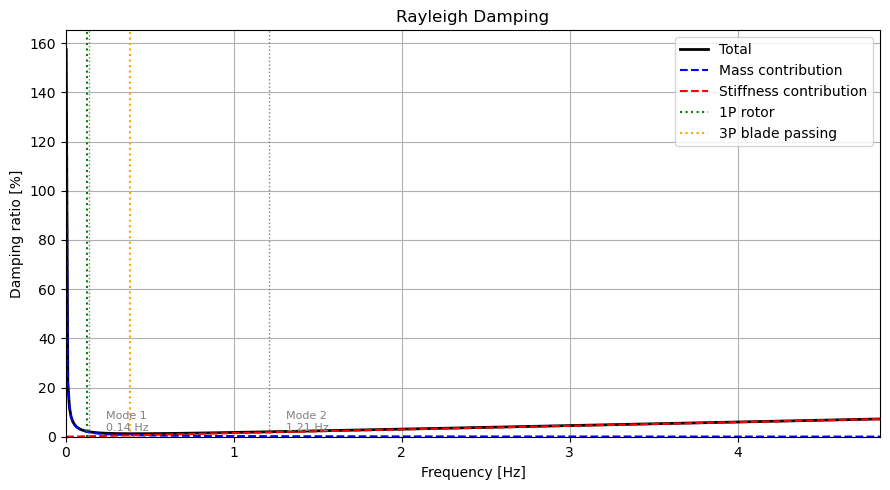

In [9]:
#--- Rayleigh damping
omega_range=np.linspace(0.01, 4*w2,500) #frequency range [rad/s]
zeta_total=alpha/(2*omega_range)+beta*omega_range/2
zeta_mass = alpha/(2*omega_range)  # mass term - dominates at low frequencies
zeta_stiff=beta*omega_range/2    # stiffness term - dominates at high frequencies

fig2, ax = plt.subplots(figsize=(9,5))

ax.plot(omega_range/(2*np.pi), zeta_total*100, 'k', linewidth=2, label='Total')
ax.plot(omega_range/(2*np.pi), zeta_mass*100, 'b--', linewidth=1.5,label= 'Mass contribution')
ax.plot(omega_range/(2*np.pi), zeta_stiff*100, 'r--', linewidth=1.5, label='Stiffness contribution')

ax.axvline(w1/(2*np.pi), color='gray', linestyle=':', linewidth=1)
ax.axvline(w2/(2*np.pi), color='gray', linestyle=':', linewidth=1)
ax.axvline(f_1P, color='green', linestyle=':', linewidth=1.5, label='1P rotor')
ax.axvline(f_3P, color='orange', linestyle=':', linewidth=1.5, label='3P blade passing')

ax.annotate(f'Mode 1\n{w1/(2*np.pi):.2f} Hz',
            xy=(w1/(2*np.pi), zeta1*100), xytext=(w1/(2*np.pi)+0.1, zeta1*100+0.3),
            fontsize=8, color='gray')
ax.annotate(f'Mode 2\n{w2/(2*np.pi):.2f} Hz',
            xy=(w2/(2*np.pi), zeta2*100), xytext=(w2/(2*np.pi)+0.1, zeta2*100+0.3),
            fontsize=8, color='gray')

ax.set_xlim(0,4*w2/(2*np.pi))
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Damping ratio [%]')
ax.set_title('Rayleigh Damping')
ax.legend()
ax.grid(True)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()




In [10]:
# verify damping ratios

zeta1_check=alpha/(2*w1)+beta*w1/2
zeta2_check=alpha/(2*w2)+beta*w2/2

print(f"Damping at mode 1: {zeta1_check*100:.2f}%")
print(f"Damping at mode 2: {zeta2_check*100:.2f}%")

output_dir = NOTEBOOK_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# === SAVE OUTPUTS =====
np.savez(output_dir / 'fem_results.npz',
    K_free         = K_free,
    M_free         = M_free, 
    C_free        = C_free, 
    freq           = freq,
    omega          = omega, 
    eigenvectors   = eigenvectors, 
    D0             =D0,
    t              =t,
    EI             =EI,
    rhoA           =rhoA,
    le             =le,
    Hw             =Hw,
    Ha             =Ha,
    L              =L,
    elem_w         =elem_w, 
    elem_a         =elem_a, 
    ndof           =ndof, 
    M_nacelle      =M_nacelle
)
print("FEM results saved to outputs/fem_results.npz")

Damping at mode 1: 2.00%
Damping at mode 2: 2.00%
FEM results saved to outputs/fem_results.npz
